# jacscanomaly: C++ template-scan workflow

This notebook runs the current standard workflow: automatic PSPL initialization, the native C++ single-lens fit and grid scan, candidate-quality inspection, and high-resolution diagnostic plots.  It uses the bundled Roman-like light curve and leaves results unexecuted so that the output reflects your installed version.

The default backend is C++; it is set explicitly below to make the execution path reproducible.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from jacscanomaly import Finder, FinderConfig

# Retina-like inline rendering and crisp saved figures.
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats

    set_matplotlib_formats("retina")
except ImportError:  # also works when run outside Jupyter
    pass

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 320,
    "figure.figsize": (6, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

notebook_started = perf_counter()

## 1. Load a light curve

The path lookup works whether the notebook is opened from `example/` or executed from the repository root. Input columns are time, flux, and 1σ flux error.

In [2]:
data_path = Path("example_data.npy")
if not data_path.exists():
    data_path = Path("example/example_data.npy")

time, flux, ferr = np.load(data_path).T
print(f"Loaded {time.size:,} measurements from {data_path}")
print(f"Time span: {time.min():.3f} to {time.max():.3f}")

Loaded 40,540 measurements from example_data.npy
Time span: 8346.502 to 10059.243


## 2. Run the standard scan

`Finder` first estimates a PSPL starting point, refines it, then scans residuals with the bell-template grid. `grid_backend="cpp"` and `single_fit_backend="cpp"` are the production defaults for this PSPL workflow.

In [3]:
config = FinderConfig(
    fitter_kind="pspl",
    grid_backend="cpp",
    single_fit_backend="cpp",
)
finder = Finder(config)
scan_started = perf_counter()
result = finder.run(time, flux, ferr)
scan_elapsed = perf_counter() - scan_started

result.print_summary()
print(f"\nC++ fit + template scan: {scan_elapsed:.2f} s")
display(result.summary_table())

=== jacscanomaly summary ===
points      : 40540
seasons     : 6
grid total  : 338514
clusters    : 1274
chi2 / dof  : 0.998

=== best candidate ===
t0          : 9826.000710
teff        : 0.299662
dchi2       : 111.242
score       : 39.292

=== quality ===
n_window    : 169
n_contrib   : 0
n_eff       : 42.326
peak_frac   : 0.072
rho1        : 0.208
longest_run : 0

C++ fit + template scan: 1.29 s


,n_points,n_seasons,n_clusters,n_grid_total,chi2_dof,has_best,best_t0,best_teff,best_dchi2,best_score,best_n_window,best_n_contrib,best_n_eff,best_peak_frac,best_rho1,best_longest_run
0,40540,6,1274,338514,0.998321,True,9826.00071,0.299662,111.24223,39.291539,169,0,42.326234,0.071693,0.207581,0


## 3. Inspect the fitted baseline and candidate support

The fit exposes named nonlinear parameters, while the best candidate carries support diagnostics. In particular, inspect `n_eff` and `peak_frac` before treating a large Δχ² as a credible anomaly.

In [4]:
fit_parameters = dict(zip(result.fit.param_names, np.asarray(result.fit.params)))
fit_parameters.update(fs=float(result.fit.fs), fb=float(result.fit.fb), chi2_dof=float(result.chi2_dof))
display(fit_parameters)

if result.best is None:
    print("No anomaly candidate passed the grid extraction thresholds.")
else:
    candidate = result.best
    quality = candidate.quality
    print(f"Candidate: t0={candidate.t0:.6f}, teff={candidate.teff:.4g}, Δχ²={candidate.dchi2:.2f}")
    print(
        f"Support: n_eff={quality.n_eff:.2f}, n_window={quality.n_window}, "
        f"peak_frac={quality.peak_frac:.3f}, rho1={quality.rho1:.3f}"
    )

{'t0': np.float64(9826.560720065758),
 'tE': np.float64(8.616036939402655),
 'u0': np.float64(-0.353279271392097),
 'fs': 9.661704644378537e-10,
 'fb': 1.5384131319444185e-09,
 'chi2_dof': 0.9983208209078956}

Candidate: t0=9826.000710, teff=0.2997, Δχ²=111.24
Support: n_eff=42.33, n_window=169, peak_frac=0.072, rho1=0.208


## 4. High-resolution diagnostics

The first figure combines the model, residuals, and grid clusters. The second zooms into the strongest candidate and overlays the local anomaly template. Both use Retina-style notebook rendering and 320 DPI when saved.

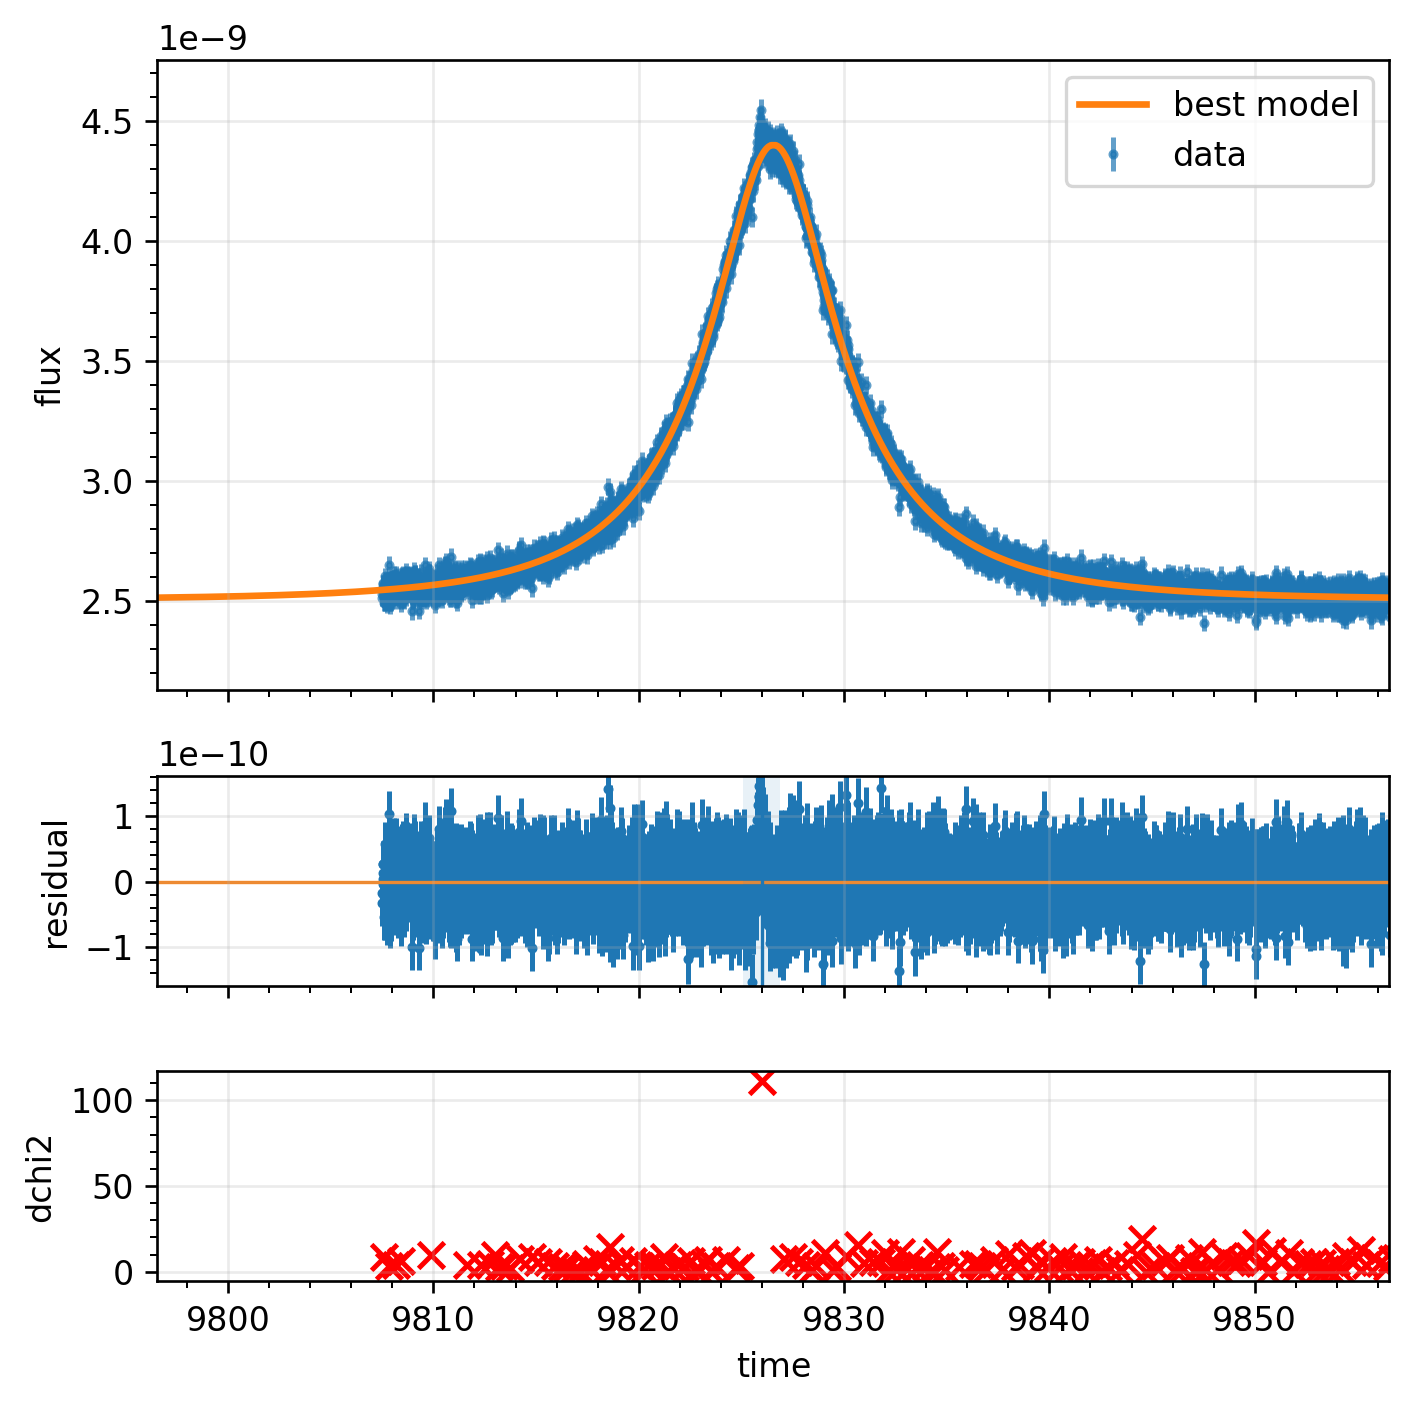

In [5]:
fig, axes = finder.plot_result(
    show=False,
    figsize=(6, 6),
    show_anomaly_window=True,
    model_base_points=256,
)
fig.tight_layout()
plt.show()

# Uncomment to create a publication-ready raster image.
# fig.savefig("template_scan_overview.png", bbox_inches="tight")

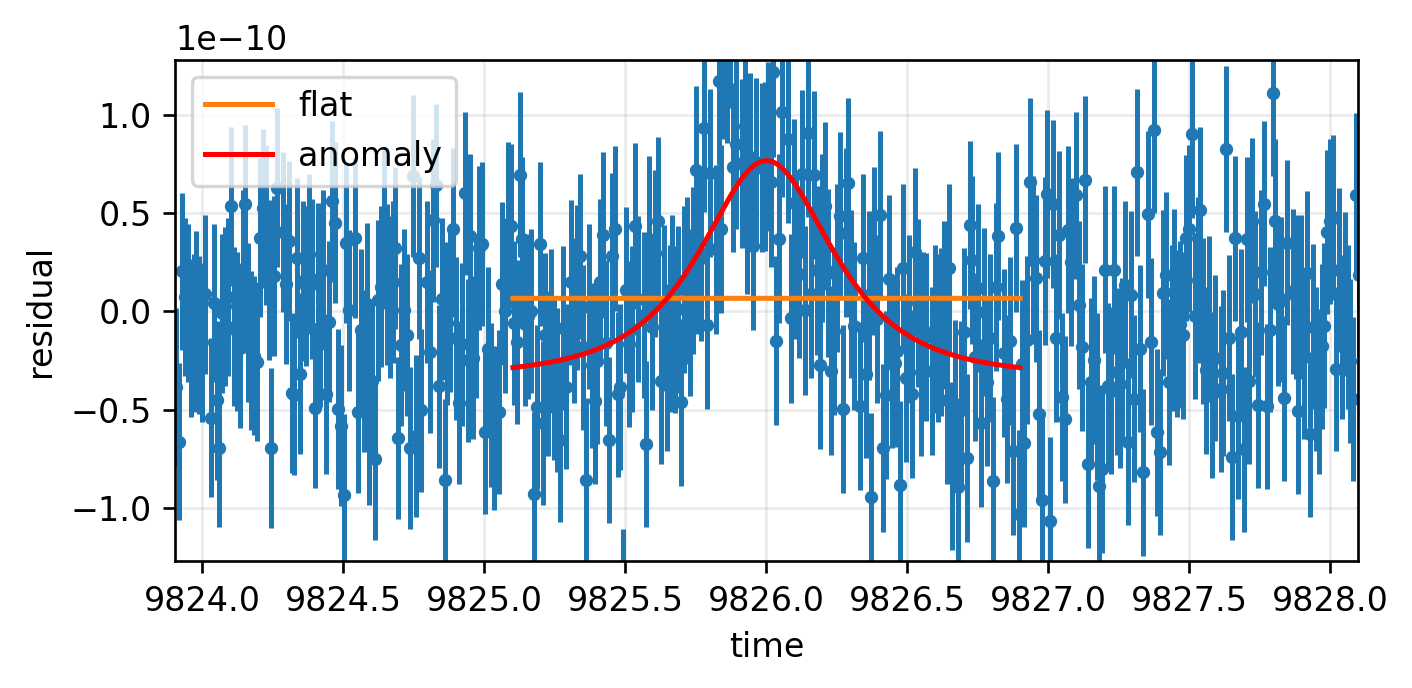

In [6]:
if result.best is not None:
    fig, ax = finder.plot_anomaly_window(show=False, a=7.0)
    fig.set_size_inches(6, 3.0)
    fig.tight_layout()
    plt.show()

## 5. Extract a localized signal and refine the baseline

`PlanetSignalExtractor` temporarily excludes a localized signal interval while refitting the PSPL baseline, then evaluates that baseline on every point. Here the strongest scan candidate supplies a follow-up window. This is a measurement workflow, not a physical 2L1S confirmation; inspect the resulting shape significance before interpreting it.

In [7]:
from jacscanomaly import PlanetSignalConfig, PlanetSignalExtractor

if result.best is None:
    signal = None
    print("No scan candidate is available to seed signal extraction.")
else:
    candidate = result.best
    signal_started = perf_counter()
    signal = PlanetSignalExtractor(
        finder,
        PlanetSignalConfig(beam_max_iter=0),
    ).run(
        time,
        flux,
        ferr,
        x0=result.fit.params,
        refit=False,
        prior_signal_windows=((candidate.t0, 4.0 * candidate.teff),),
    )
    signal_elapsed = perf_counter() - signal_started

    classification = signal.classify()
    anomaly_estimate = signal.classify_anomaly()
    print(f"Masked signal points: {signal.signal_mask.sum():,}")
    print(
        f"Baseline χ²/dof: {signal.initial_fit.chi2_dof:.4f} → "
        f"{signal.refined_fit.chi2_dof:.4f}"
    )
    print(f"Signal shape: {classification.signal_type}")
    print(f"Signal extraction: {signal_elapsed:.2f} s")
    print(anomaly_estimate.summary_text())

Masked signal points: 225
Baseline χ²/dof: 0.9983 → 0.9989
Signal shape: low_significance
Signal extraction: 0.35 s
best_shape: fold
components: 1
best_fit: fold (delta_chi2=128.5, bic=246.0)
geometry: tau_anom=-0.0867, u_anom=0.3733, alpha=1.8052 rad, s_dagger(+)=1.2039, s_dagger(-)=0.8306, branch=unknown, regime=planetary
scales: tstar/tE=0.01835


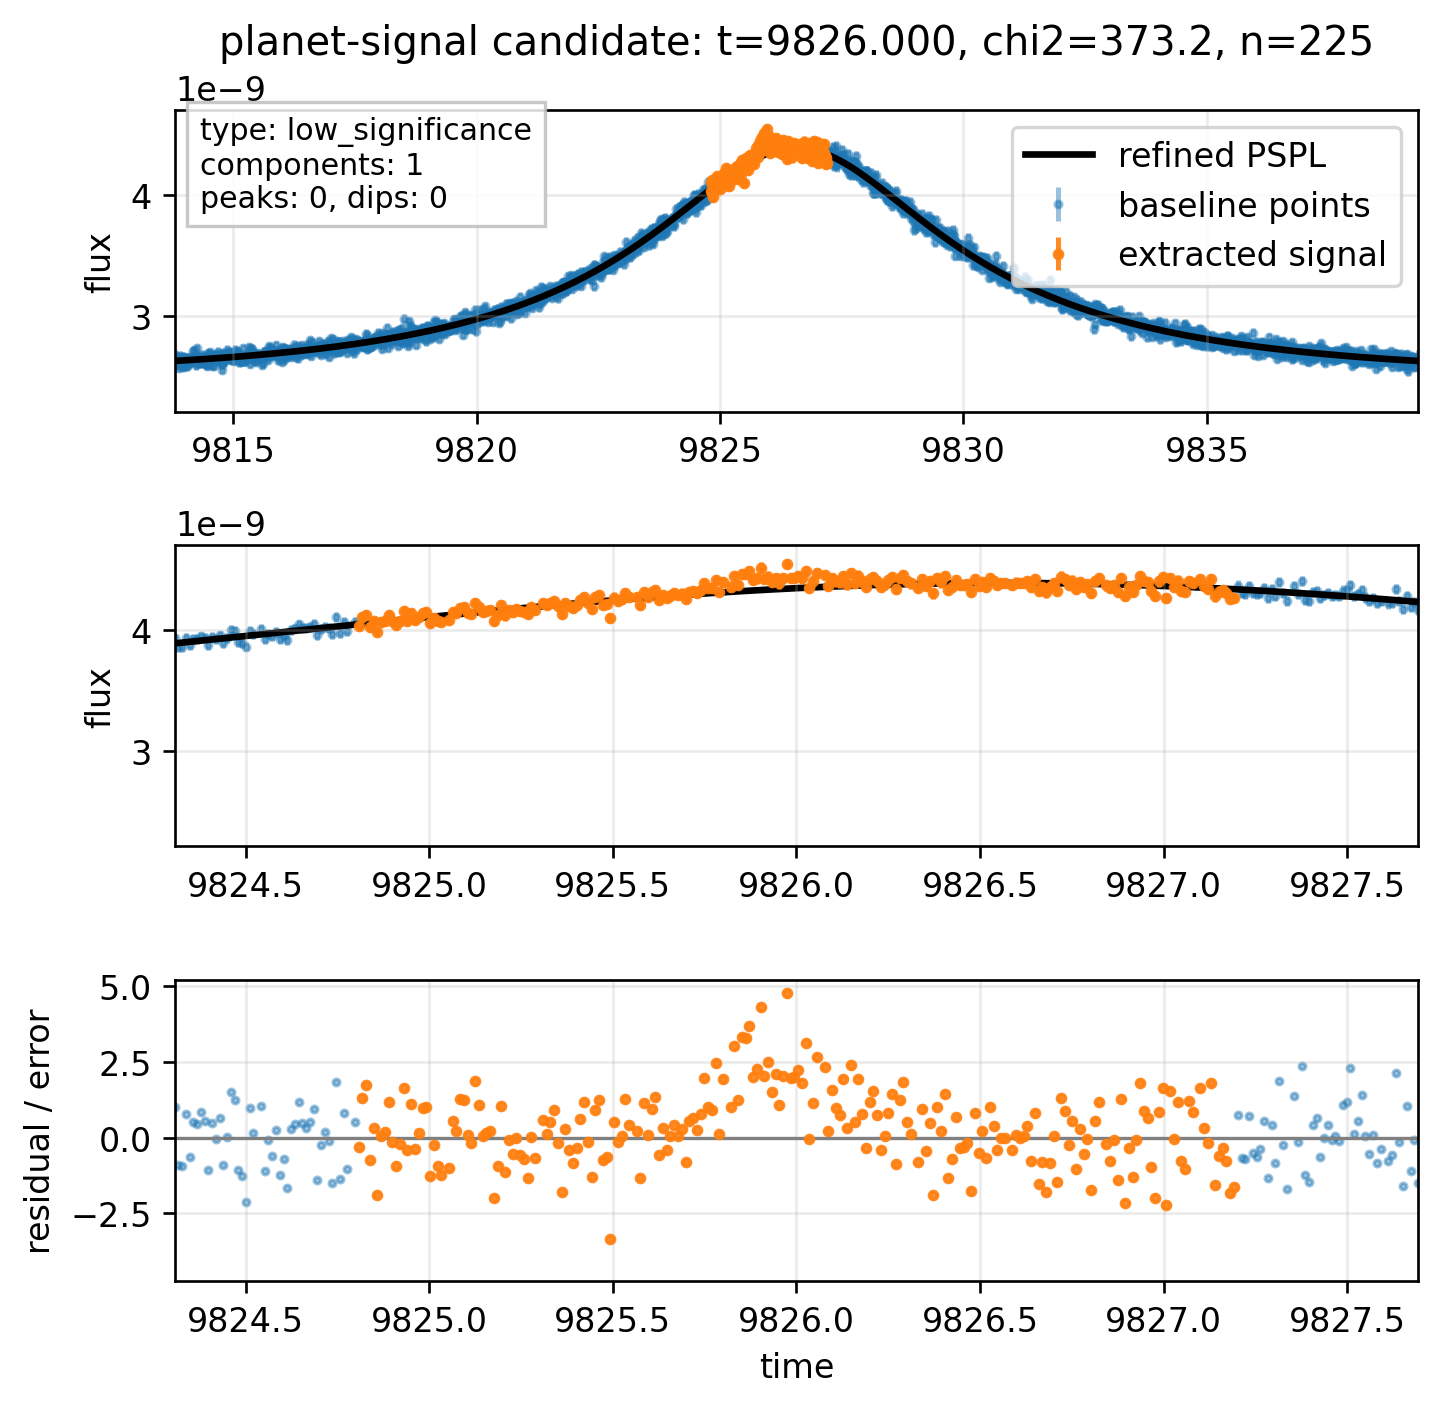

Notebook elapsed time: 7.70 s


In [8]:
if signal is not None:
    fig, axes = signal.plot_signal(show=False)
    fig.set_size_inches(6, 6)
    fig.tight_layout()
    plt.show()

print(f"Notebook elapsed time: {perf_counter() - notebook_started:.2f} s")

## Next steps

- Add `CandidateCriteria(...)` to `FinderConfig` when your survey has explicit support requirements (for example, a minimum effective number of contributing points).
- For residual-only, zero-crossing searches, see `template_free_example.ipynb`.
- For a coherent extracted residual signal, use `PlanetSignalExtractor` followed by `classify_anomaly()` to obtain shape measurements and a 2L1S grid-search seed.
- Use `fitter_kind="fspl_parallax"` with `single_fit_backend="vbm_cpp"` when you have source coordinates and need the native VBM finite-source/parallax workflow.